# Cosmo Care Anomaly Detection and RAG Pipeline

In [ ]:
%pip install numpy pandas scikit-learn matplotlib shap

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.9 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.8 MB/s  0:00:00
  Created wheel for ibm-cos-sdk: filename=ibm_cos_sdk-2.14.3-py3-none-any.whl size=77323 sha256=39c085b80f4c607cb06fc463098ca588fb86b2a4c21633bcaeb99a2355af1c1d
  Stored in directory: /home/hamim/.cache/pip/wheels/25/86/01/2c2de306271d602bd21d1200d405f0f1846d8bd7ad97e0adc6
  Created wheel for ibm-cos-sdk-core: filename=ibm_cos_sdk_core-2.14.3-py3-none-any.whl size=662208 sha256=b83de80e5c87433e5e5ac4ed31aee79d4935e6f4caecd7b6967b723bc1fbb10f

## Data Cleaning

We use the HealthRing dataset, which provides key vitals such as heart rate, respiratory rate, and SpO2 levels in healthy humans.

In [ ]:
import pickle

# inspecting contents of HealthRing Dataset
df = None
with open("data/00012_ring2_processed.pkl", "rb") as f:
    df = pickle.load(f)

df.head()

/tmp/ipykernel_20064/701970548.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


,id,start,end,fs,ir-raw,ir-standardized,ir-filtered,ir-difference,ir-welch,ir-filtered-rr,...,bvp_nn50,bvp_pnn50,resp_rr,spo2,samsung_hr,oura_hr,BP_sys,BP_dia,Experiment,Label
0,0,1.742697e+09,1.742697e+09,99.701524,"[579937, 579784, 579991, 579558, 580124, 58043...","[-0.7371179659010175, -0.751210023620453, -0.7...","[0.03760081467890073, 0.04457045040531995, 0.0...","[0.34538710948770945, 0.3572443975349071, 0.37...","[0.0006755964901876854, 0.00068124307018795, 0...","[-0.09150874938755045, -0.0868388576482947, -0...",...,1,2.380952,24.529448,98.0,None,None,85.0,63.0,Health,sitting
1,1,1.742697e+09,1.742697e+09,99.935010,"[572078, 572354, 572453, 573208, 573195, 57308...","[0.4990631958630084, 0.5798607894076976, 0.608...","[-0.0461001668537677, -0.012284576825429928, 0...","[0.6109161108131311, 0.5884055913592209, 0.558...","[0.0013708227838428292, 0.001379090127826787, ...","[0.3769013840865046, 0.3885585481475044, 0.400...",...,5,11.363636,18.397069,98.0,None,None,85.0,63.0,Health,sitting
2,2,1.742697e+09,1.742697e+09,99.949786,"[571124, 570273, 569279, 568566, 567913, 56736...","[0.3127587419554466, 0.07971555696567298, -0.1...","[-0.11780171684682562, -0.2506316733362167, -0...","[-2.2826150099469746, -2.240893086282598, -2.1...","[0.0017027899958639407, 0.0017158866707144686,...","[-0.029170245929245598, -0.039905995563454484,...",...,4,9.302326,19.931172,98.0,None,None,None,None,Health,sitting
3,3,1.742697e+09,1.742697e+09,100.122381,"[562670, 562927, 563174, 563353, 563595, 56385...","[-1.0511561405999672, -0.9870498810586342, -0....","[-0.118024257676731, -0.0928799613264786, -0.0...","[0.4764153443113916, 0.45079315177208007, 0.41...","[0.0012261603302239667, 0.0012323272422347239,...","[0.029666674247258263, 0.04400991356908477, 0....",...,0,0.0,19.931305,98.0,None,None,None,None,Health,sitting
4,4,1.742697e+09,1.742697e+09,100.005086,"[565342, 564218, 563711, 562732, 562071, 56091...","[-0.1727759540456088, -0.4690780004264144, -0....","[-0.16036486297675936, -0.29861931093288974, -...","[-2.5559366818937947, -2.5166063163710626, -2....","[0.0013432495844531104, 0.0013581919899527852,...","[-0.4075907560770166, -0.42287013997383666, -0...",...,2,4.545455,19.930453,98.233333,None,None,None,None,Health,sitting


We collate the separate `.pkl` files of the dataset into one `master.csv` to be feature engineered for training.

In [72]:
import pickle
import glob
import pandas as pd
from pathlib import Path
import re

# Columns you actually need for the master dataframe
KEEP_COLS = [
    "start", "end",
    "hr", "spo2", "resp_rr",
    # "BP_sys", "BP_dia", --- data is missing for multiple subjects, leave out for now
    # "Label" --- could be useful later, but largely will use rolling windows of other features instead
]

def load_one_pkl(path):
    with open(path, "rb") as f:
        df = pickle.load(f)

    # 1. Filter keep columns
    missing = [c for c in KEEP_COLS if c not in df.columns]
    if missing:
        print(f"[warn] {path} missing columns: {missing}")

    # Select only available columns from KEEP_COLS
    available_cols = [c for c in KEEP_COLS if c in df.columns]
    out = df[available_cols].copy()

    # 2. Extract subject_id and ring using Python's 're' module
    filename = path.name if hasattr(path, "name") else str(path)
    match = re.search(r'(\d+)_ring(\d+)_processed\.pkl', filename)

    if match:
        out['id'] = int(match.group(1)) # Strips leading zeros automatically
        out['ring'] = int(match.group(2))
    else:
        print(f"[warn] Could not parse filename pattern for: {filename}")
        out['id'] = None
        out['ring'] = None

    return out

def build_master_dataframe(pkl_dir, pattern="*.pkl"):
    paths = sorted(glob.glob(str(Path(pkl_dir) / pattern)))
    if not paths:
        raise FileNotFoundError(f"No pkl files found in {pkl_dir}")

    frames = []
    for p in paths:
        try:
            frames.append(load_one_pkl(p))
        except Exception as e:
            print(f"[error] failed to load {p}: {e}")

    master = pd.concat(frames, ignore_index=True)

    # order each person's windows chronologically
    master = master.sort_values(["id", "ring", "start"]).reset_index(drop=True)

    return master

# --- usage ---
master_df = build_master_dataframe("data/")
master_df = master_df[['id', 'ring'] + KEEP_COLS]

print(master_df.shape)
print(master_df["id"].nunique(), "unique people")
print(master_df.head())

# save for reuse
master_df.to_csv('master.csv')

/tmp/ipykernel_20064/932428124.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


(3422, 7)
28 unique people
   id  ring         start           end         hr       spo2    resp_rr
0   0     1  1.742608e+09  1.742608e+09  80.633333       96.0   9.089016
1   0     1  1.742608e+09  1.742608e+09       79.4       95.8  13.635623
2   0     1  1.742608e+09  1.742608e+09       78.0       96.6   10.72377
3   0     1  1.742608e+09  1.742608e+09  81.966667       96.8  12.019393
4   0     1  1.742608e+09  1.742608e+09  81.533333  96.233333  12.178545


In [73]:
df = master_df

vitals = ['hr', 'spo2', 'resp_rr']

for col in vitals:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[vitals] = (
    df.groupby(['id', 'ring'])[vitals]
    .transform(lambda group: group.interpolate(method='linear', limit_direction='both'))
)

## Feature Engineering

Our primary synthetic features are rolling windows over the HealthRing dataset vitals, which will give the model context of an individual's baseline telemetry and enable the prediction of medical emergencies before they occur.

In [ ]:
import numpy as np
import pandas as pd

RANDOM_SEED = 42
TIME_UNIT = "s"  

def _rolling_slope_raw(x):
    if len(x) < 2:
        return 0.0
    return np.polyfit(np.arange(len(x)), x, 1)[0]

def add_rolling_features(df, time_windows=("30s", "120s", "600s"), time_unit=TIME_UNIT):
    df = df.sort_values(["id", "ring", "start"]).reset_index(drop=True)
    df["_start_dt"] = pd.to_datetime(df["start"], unit=time_unit)

    vitals = ["hr", "spo2", "resp_rr"]
    group_cols = ["id", "ring"]  # never mixed, even for the same id

    pieces = []
    for _, g in df.groupby(group_cols, sort=False):
        g = g.set_index("_start_dt").sort_index()
        for vital in vitals:
            for w in time_windows:
                g[f"{vital}_roll_mean_{w}"] = g[vital].rolling(w, min_periods=1).mean()
                g[f"{vital}_roll_std_{w}"] = g[vital].rolling(w, min_periods=2).std()
                g[f"{vital}_roll_slope_{w}"] = (
                    g[vital].rolling(w, min_periods=2).apply(_rolling_slope_raw, raw=True)
                )
            g[f"{vital}_dev_from_roll"] = g[vital] - g[f"{vital}_roll_mean_{time_windows[0]}"]
        pieces.append(g.reset_index())

    out = pd.concat(pieces, ignore_index=True)

    # Early rows in each id/ring session won't have a full window yet.
    # Borrow the nearest computable value within the same session, then
    # zero-fill anything still missing.
    roll_cols = [c for c in out.columns if "_roll_" in c or c.endswith("_dev_from_roll")]
    out[roll_cols] = out.groupby(group_cols)[roll_cols].transform(lambda s: s.bfill().ffill())
    out[roll_cols] = out[roll_cols].fillna(0)

    return out.drop(columns=["_start_dt"])


feat_df = add_rolling_features(df, time_windows=("30s", "120s", "600s"))
print(f"{feat_df.shape[1] - df.shape[1]} rolling feature columns added")
feat_df.head()

30 rolling feature columns added


,id,ring,start,end,hr,spo2,resp_rr,hr_roll_mean_30s,hr_roll_std_30s,hr_roll_slope_30s,...,resp_rr_roll_mean_30s,resp_rr_roll_std_30s,resp_rr_roll_slope_30s,resp_rr_roll_mean_120s,resp_rr_roll_std_120s,resp_rr_roll_slope_120s,resp_rr_roll_mean_600s,resp_rr_roll_std_600s,resp_rr_roll_slope_600s,resp_rr_dev_from_roll
0,0,1,1.742608e+09,1.742608e+09,80.633333,96.000000,9.089016,80.633333,0.872098,-1.233333,...,9.089016,3.214937,4.546607,9.089016,3.214937,4.546607,9.089016,3.214937,4.546607,0.000000
1,0,1,1.742608e+09,1.742608e+09,79.400000,95.800000,13.635623,80.016667,0.872098,-1.233333,...,11.362319,3.214937,4.546607,11.362319,3.214937,4.546607,11.362319,3.214937,4.546607,2.273304
2,0,1,1.742608e+09,1.742608e+09,78.000000,96.600000,10.723770,78.000000,2.804857,3.966667,...,10.723770,0.916144,1.295623,11.149470,2.303003,0.817377,11.149470,2.303003,0.817377,0.000000
3,0,1,1.742608e+09,1.742608e+09,81.966667,96.800000,12.019393,79.983333,2.804857,3.966667,...,11.371581,0.916144,1.295623,11.366950,1.930045,0.587928,11.366950,1.930045,0.587928,0.647812
4,0,1,1.742608e+09,1.742608e+09,81.533333,96.233333,12.178545,81.750000,0.306413,-0.433333,...,12.098969,0.112537,0.159152,11.529269,1.710422,0.456283,11.529269,1.710422,0.456283,0.079576


## Train/Test

In [78]:
from sklearn.model_selection import GroupShuffleSplit

meta_cols = ["id", "ring", "start", "end"]
feature_cols = [c for c in feat_df.columns if c not in meta_cols]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(feat_df, groups=feat_df["id"]))

train_df = feat_df.iloc[train_idx].reset_index(drop=True)
test_df = feat_df.iloc[test_idx].reset_index(drop=True)

assert set(train_df["id"]).isdisjoint(set(test_df["id"])), "ID leakage between train/test!"

print(f"train: {train_df.shape}, unique ids: {train_df['id'].nunique()}")
print(f"test:  {test_df.shape}, unique ids: {test_df['id'].nunique()}")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

train: (2934, 37), unique ids: 22
test:  (488, 37), unique ids: 6


In [79]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
iso_forest.fit(X_train)

train_df["anomaly_score"] = iso_forest.decision_function(X_train)   # higher = more normal
train_df["anomaly_pred"] = iso_forest.predict(X_train)              # -1 = anomaly, 1 = normal

test_df["anomaly_score"] = iso_forest.decision_function(X_test)
test_df["anomaly_pred"] = iso_forest.predict(X_test)

print("Train anomaly rate:", (train_df["anomaly_pred"] == -1).mean())
print("Test anomaly rate:", (test_df["anomaly_pred"] == -1).mean())

Train anomaly rate: 0.06100886162235856
Test anomaly rate: 0.06967213114754098


In [80]:
test_df.sort_values("anomaly_score").head(15)[
    ["id", "ring", "start", "hr", "spo2", "resp_rr", "anomaly_score"]
]

,id,ring,start,hr,spo2,resp_rr,anomaly_score
178,10,1,1.742652e+09,97.900000,94.700000,7.658529,-0.095523
390,22,2,1.742820e+09,78.482759,92.206897,9.182210,-0.087905
345,22,1,1.742820e+09,78.482759,92.206897,9.182145,-0.082409
177,10,1,1.742652e+09,108.100000,88.666667,6.126988,-0.072428
214,10,2,1.742652e+09,108.100000,88.666667,6.127205,-0.072041
344,22,1,1.742820e+09,85.172414,89.206897,26.017682,-0.062730
389,22,2,1.742820e+09,85.172414,89.206897,26.017588,-0.062730
341,22,1,1.742820e+09,87.000000,83.533333,19.895150,-0.058945
456,26,2,1.743057e+09,86.000000,98.633333,9.163902,-0.051983
346,22,1,1.742820e+09,73.866667,96.066667,15.312399,-0.040881


In [81]:
test_df[test_df["anomaly_pred"] == -1].groupby(["id", "ring"]).size().sort_values(ascending=False)

id  ring
22  1       8
    2       7
26  2       7
10  1       6
    2       5
9   1       1
dtype: int64

In [82]:
test_df["is_early_row"] = test_df.groupby(["id","ring"]).cumcount() < 5
test_df.groupby("is_early_row")["anomaly_pred"].apply(lambda s: (s == -1).mean())

is_early_row
False    0.076212
True     0.018182
Name: anomaly_pred, dtype: float64

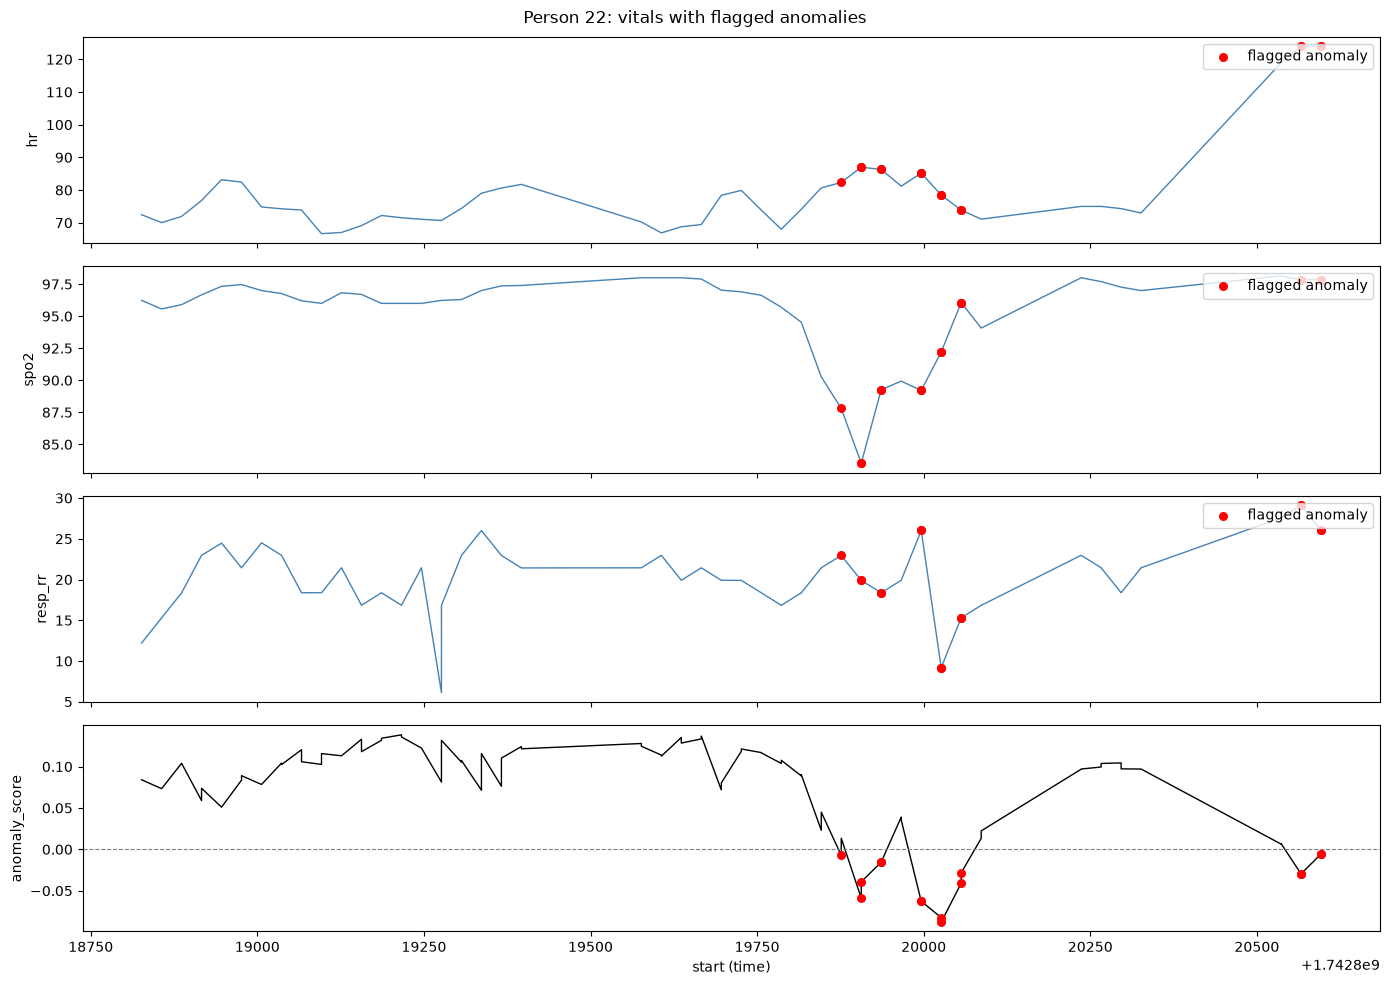

In [85]:
import matplotlib.pyplot as plt

def plot_person_anomalies(df, person_id, vitals=("hr", "spo2", "resp_rr")):
    person_df = df[df["id"] == person_id].sort_values("start")
    anomalies = person_df[person_df["anomaly_pred"] == -1]

    fig, axes = plt.subplots(len(vitals) + 1, 1, figsize=(14, 10), sharex=True)

    for ax, vital in zip(axes[:-1], vitals):
        ax.plot(person_df["start"], person_df[vital], color="steelblue", linewidth=1)
        ax.scatter(anomalies["start"], anomalies[vital], color="red", zorder=5, s=30, label="flagged anomaly")
        ax.set_ylabel(vital)
        ax.legend(loc="upper right")

    axes[-1].plot(person_df["start"], person_df["anomaly_score"], color="black", linewidth=1)
    axes[-1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[-1].scatter(anomalies["start"], anomalies["anomaly_score"], color="red", zorder=5, s=30)
    axes[-1].set_ylabel("anomaly_score")
    axes[-1].set_xlabel("start (time)")

    fig.suptitle(f"Person {person_id}: vitals with flagged anomalies")
    plt.tight_layout()
    plt.show()

plot_person_anomalies(test_df, person_id=22)

Shapley values are used to score the contribution of each vital to the occurence of the anomaly. Essentially, it lets us map the raw anomaly outputs of the Isolation Forest to a human-interpretable category (e.g. cardiovascular, respiratory).

In [ ]:
import shap
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(iso_forest)

X_test_sample = X_test

shap_values = explainer.shap_values(X_test_sample)
shap_df = pd.DataFrame(shap_values, columns=X_test_sample.columns, index=X_test_sample.index)

print(shap_df.shape)
shap_df.head()

/home/hamim/.conda/envs/cosmo-care/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(488, 33)


,hr,spo2,resp_rr,hr_roll_mean_30s,hr_roll_std_30s,hr_roll_slope_30s,hr_roll_mean_120s,hr_roll_std_120s,hr_roll_slope_120s,hr_roll_mean_600s,...,resp_rr_roll_mean_30s,resp_rr_roll_std_30s,resp_rr_roll_slope_30s,resp_rr_roll_mean_120s,resp_rr_roll_std_120s,resp_rr_roll_slope_120s,resp_rr_roll_mean_600s,resp_rr_roll_std_600s,resp_rr_roll_slope_600s,resp_rr_dev_from_roll
0,0.057546,0.020395,-0.263849,0.053279,0.062896,0.033070,0.094405,0.044802,0.030605,0.093516,...,-0.265705,-0.097839,-0.021055,-0.224165,-0.009512,-0.336277,-0.310662,0.051883,-0.604636,0.081547
1,0.065833,0.007931,0.055654,0.058462,0.070885,0.042533,0.100085,0.042326,0.027813,0.096578,...,-0.107504,-0.089648,-0.023408,-0.027950,-0.006068,-0.326803,-0.228591,0.051789,-0.662608,-0.289752
2,0.046163,0.038001,-0.115673,0.070071,0.012324,-0.009002,0.106979,0.054934,0.007615,0.119614,...,-0.186391,0.099209,0.049301,-0.014384,0.091400,0.019578,-0.276683,0.080743,-0.030944,0.072293
3,0.044926,0.032218,-0.095037,0.059904,0.004624,-0.002978,0.100707,0.063182,0.076211,0.082485,...,-0.168091,0.097469,0.048052,0.006646,0.104744,0.046023,-0.313619,0.082237,0.017601,-0.003979
4,0.044874,0.020352,-0.017811,0.061231,0.060549,0.066939,0.090672,0.048415,0.055655,0.096183,...,-0.094013,0.055281,0.058808,0.008107,0.104906,0.043801,-0.302261,0.088637,0.011155,0.069362


In [89]:
def top_contributors(shap_row, n=5):
    # most negative SHAP values = features pushing this window toward anomalous
    return shap_row.sort_values().head(n)

# example: explain the single most anomalous test window
worst_idx = test_df.loc[X_test_sample.index, "anomaly_score"].idxmin()
print(f"Window at index {worst_idx}, anomaly_score={test_df.loc[worst_idx, 'anomaly_score']:.4f}")
print(top_contributors(shap_df.loc[worst_idx]))

def get_top_features(row, k=3):
    top = row.sort_values().head(k)
    return list(zip(top.index, top.round(4)))

test_df.loc[X_test_sample.index, "top_shap_features"] = shap_df.apply(
    lambda row: get_top_features(row, k=3), axis=1
)

test_df.loc[X_test_sample.index, ["id", "start", "anomaly_score", "top_shap_features"]].sort_values(
    "anomaly_score"
).head(10)

Window at index 178, anomaly_score=-0.0955
spo2_roll_std_30s       -0.834046
spo2_roll_slope_30s     -0.642596
spo2_roll_std_120s      -0.420098
resp_rr                 -0.381440
resp_rr_roll_mean_30s   -0.339792
Name: 178, dtype: float64


,id,start,anomaly_score,top_shap_features
178,10,1.742652e+09,-0.095523,"[(spo2_roll_std_30s, -0.834), (spo2_roll_slope..."
390,22,1.742820e+09,-0.087905,"[(resp_rr_roll_std_30s, -0.9696), (resp_rr_dev..."
345,22,1.742820e+09,-0.082409,"[(resp_rr_roll_std_30s, -1.0049), (resp_rr_dev..."
177,10,1.742652e+09,-0.072428,"[(resp_rr_roll_std_30s, -0.6569), (spo2_roll_m..."
214,10,1.742652e+09,-0.072041,"[(resp_rr_roll_std_30s, -0.6561), (spo2_roll_m..."
344,22,1.742820e+09,-0.062730,"[(resp_rr_roll_std_30s, -1.0682), (resp_rr_rol..."
389,22,1.742820e+09,-0.062730,"[(resp_rr_roll_std_30s, -1.0682), (resp_rr_rol..."
341,22,1.742820e+09,-0.058945,"[(spo2, -0.8097), (spo2_roll_std_30s, -0.7013)..."
456,26,1.743057e+09,-0.051983,"[(resp_rr_roll_std_30s, -1.209), (resp_rr_dev_..."
346,22,1.742820e+09,-0.040881,"[(spo2_roll_std_30s, -0.7124), (resp_rr_roll_s..."


In [90]:
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print(mean_abs_shap.head(15))

resp_rr_roll_std_120s      0.149509
resp_rr_roll_std_30s       0.139831
hr_roll_mean_120s          0.126730
spo2_roll_std_600s         0.116451
hr_roll_mean_600s          0.111694
resp_rr_roll_mean_30s      0.108739
resp_rr_dev_from_roll      0.099022
spo2_roll_std_120s         0.098973
spo2_roll_std_30s          0.098602
spo2_roll_slope_600s       0.097670
resp_rr_roll_slope_600s    0.091781
spo2                       0.091689
hr_roll_mean_30s           0.091450
spo2_roll_slope_120s       0.090999
spo2_roll_mean_120s        0.085368
dtype: float64


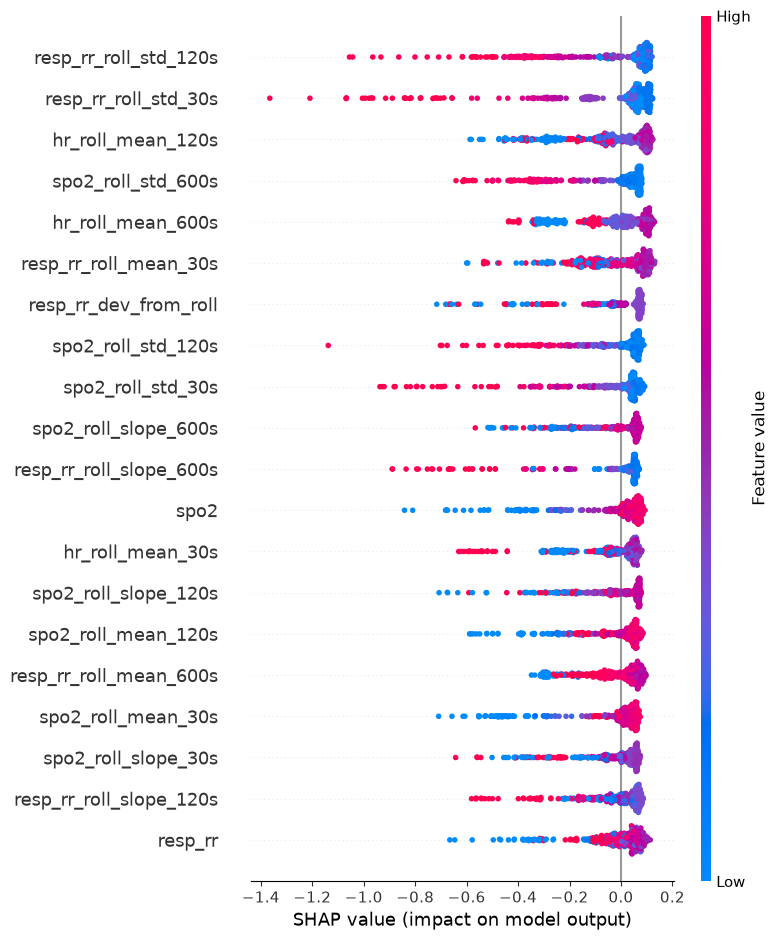

In [91]:
shap.summary_plot(shap_values, X_test_sample, show=True)

In [92]:
SYSTEM_MAP = {
    "cardiovascular": lambda col: col.startswith("hr"),
    "respiratory": lambda col: col.startswith("spo2") or col.startswith("resp_rr"),
}

def get_system_attribution(shap_row, system_map=SYSTEM_MAP):
    scores = {}
    for system, matcher in system_map.items():
        cols = [c for c in shap_row.index if matcher(c)]
        # sum of SHAP values (signed) toward anomalous for that system's features
        scores[system] = shap_row[cols].sum()
    return scores

# per-window system attribution
system_scores = shap_df.apply(get_system_attribution, axis=1, result_type="expand")
test_df.loc[X_test_sample.index, system_scores.columns] = system_scores

test_df.loc[X_test_sample.index, ["id", "start", "anomaly_score", "cardiovascular", "respiratory"]].sort_values(
    "anomaly_score"
).head(10)

,id,start,anomaly_score,cardiovascular,respiratory
178,10,1.742652e+09,-0.095523,-1.040041,-4.954816
390,22,1.742820e+09,-0.087905,-0.225742,-5.578824
345,22,1.742820e+09,-0.082409,-0.219968,-5.445772
177,10,1.742652e+09,-0.072428,-0.769555,-4.640710
214,10,1.742652e+09,-0.072041,-0.768912,-4.631353
344,22,1.742820e+09,-0.062730,-0.039033,-5.118685
389,22,1.742820e+09,-0.062730,-0.039033,-5.118685
341,22,1.742820e+09,-0.058945,-0.462122,-4.595846
456,26,1.743057e+09,-0.051983,-0.570328,-4.302373
346,22,1.742820e+09,-0.040881,-0.231953,-4.340465


## RAG System Implementation

Using the information the Isolation Forest model derives from the data stream, we develop a payload and pass it to an **IBM Granite** LLM model, which cross references official NASA astronaut manuals/guidelines for vitals/environmental conditions. This composition allows for an AI assistant that can actively understand astronaut symptoms, respond to their queries, and advise them during medical emergencies.

In [2]:
%pip install ibm-watsonx-ai langchain-ibm python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [93]:
import json

def build_alert_payload(row, shap_row, top_k=3):
    top_features = shap_row.sort_values().head(top_k)
    return {
        "person_id": str(row["id"]),
        "timestamp": float(row["start"]),
        "anomaly_score": round(float(row["anomaly_score"]), 4),
        "system_attribution": {
            "cardiovascular": round(float(row.get("cardiovascular", 0)), 4),
            "respiratory": round(float(row.get("respiratory", 0)), 4),
        },
        "top_contributing_features": [
            {"feature": feat, "shap_value": round(float(val), 4)}
            for feat, val in top_features.items()
        ],
        "raw_vitals": {
            "hr": round(float(row["hr"]), 1),
            "spo2": round(float(row["spo2"]), 1),
            "resp_rr": round(float(row["resp_rr"]), 1),
        },
        "self_reported_symptoms": None,  # not available in current data -- omit or wire up if you add it
    }

worst_idx = test_df.loc[X_test_sample.index, "anomaly_score"].idxmin()
payload = build_alert_payload(test_df.loc[worst_idx], shap_df.loc[worst_idx])
print(json.dumps(payload, indent=2))

{
  "person_id": "10",
  "timestamp": 1742652063.6381197,
  "anomaly_score": -0.0955,
  "system_attribution": {
    "cardiovascular": -1.04,
    "respiratory": -4.9548
  },
  "top_contributing_features": [
    {
      "feature": "spo2_roll_std_30s",
      "shap_value": -0.834
    },
    {
      "feature": "spo2_roll_slope_30s",
      "shap_value": -0.6426
    },
    {
      "feature": "spo2_roll_std_120s",
      "shap_value": -0.4201
    }
  ],
  "raw_vitals": {
    "hr": 97.9,
    "spo2": 94.7,
    "resp_rr": 7.7
  },
  "self_reported_symptoms": null
}


In [18]:
import os
import json
from pathlib import Path
from dotenv import load_dotenv
from pypdf import PdfReader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ibm import ChatWatsonx, WatsonxEmbeddings
from langchain_chroma import Chroma

load_dotenv()

SOURCE_DIR = "./docs"      # put your PDFs/manuals here
PERSIST_DIR = "./kb"     # vector DB gets saved/loaded here
COLLECTION_NAME = "medical_kb"
CHUNK_SIZE = 500
CHUNK_OVERLAP = 75
TOP_K = 3

Run the following cell ***exactly once***. This is only needed for creating the knowledge database.

In [21]:
def load_pdf(path: Path) -> list[Document]:
    """One Document per page, so page-level metadata survives into citations."""
    reader = PdfReader(str(path))
    docs = []
    for page_num, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        if text.strip():
            docs.append(Document(page_content=text, metadata={"source": path.name, "page": page_num + 1}))
    return docs


def load_text(path: Path) -> list[Document]:
    text = path.read_text(encoding="utf-8", errors="ignore")
    return [Document(page_content=text, metadata={"source": path.name})]


def load_documents(source_dir: str) -> list[Document]:
    source_path = Path(source_dir)
    docs = []

    for pdf_path in source_path.rglob("*.pdf"):
        docs.extend(load_pdf(pdf_path))

    for ext in ("*.txt", "*.md"):
        for text_path in source_path.rglob(ext):
            docs.extend(load_text(text_path))

    if not docs:
        raise ValueError(f"No documents found in {source_dir}. Drop your NASA PDFs/manuals there first.")

    print(f"Loaded {len(docs)} document chunks (pages/files) from {source_dir}")
    return docs

docs = load_documents(SOURCE_DIR)

def chunk_documents(docs):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = splitter.split_documents(docs)
    print(f"Split into {len(chunks)} chunks")
    return chunks

chunks = chunk_documents(docs)

embeddings = WatsonxEmbeddings(
    model_id="ibm/granite-embedding-278m-multilingual",  # IBM's retrieval-tuned embedder
    url=os.getenv("WATSONX_URL", "https://us-south.ml.cloud.ibm.com"),
    project_id=os.getenv("WATSONX_PROJECT_ID"),
    apikey=os.getenv("WATSONX_API_KEY"),
)

vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
)
print(f"Vector store built and persisted to {PERSIST_DIR}")

Loaded 465 document chunks (pages/files) from ./docs
Split into 2632 chunks
Vector store built and persisted to ./kb


In [ ]:
vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=PERSIST_DIR,
)

In [22]:
def build_retrieval_query(payload: dict, shap_drivers: list) -> str:
    top_features = ", ".join(d["feature"] for d in shap_drivers)
    telemetry_str = ", ".join(f"{k}={v}" for k, v in payload["telemetry"].items())
    return (
        f"Astronaut physiological anomaly involving {top_features}. "
        f"Current readings: {telemetry_str}. "
        f"What are the relevant safety thresholds, required actions, and EVA/mission constraints?"
    )

def retrieve(query: str, k: int = TOP_K) -> list[dict]:
    results = vector_store.similarity_search_with_score(query, k=k)
    retrieved = []
    for doc, score in results:
        retrieved.append({
            "source": doc.metadata.get("source", "unknown"),
            "page": doc.metadata.get("page", None),
            "text": doc.page_content,
            "relevance_score": float(score),  # lower = more similar (distance)
        })
    return retrieved

def build_prompt(payload: dict, retrieved: list[dict]) -> str:
    context_block = "\n\n".join(
        f"[Source: {r['source']}" + (f", p.{r['page']}" if r.get("page") is not None else "") + f"]\n{r['text']}"
        for r in retrieved
    )
    return f"""You are a spaceflight medical decision-support assistant.
Use ONLY the reference material below to ground your answer. If the
references don't cover the situation, say so explicitly rather than guessing.

REFERENCE MATERIAL:
{context_block}

ASTRONAUT DATA:
{json.dumps(payload, indent=2)}

Respond in exactly this format:
SUMMARY:
PRIMARY CONCERN:
SEVERITY:
RECOMMENDED ACTION:
SOURCE:
"""

In [ ]:
llm = ChatWatsonx(
    model_id="ibm/granite-4-h-small",
    url=os.getenv("WATSONX_URL", "https://us-south.ml.cloud.ibm.com"),
    project_id=os.getenv("WATSONX_PROJECT_ID"),
    api_key=os.getenv("WATSONX_API_KEY"),
    params={"max_tokens": 256, "temperature": 0.0},
)

payload = {
    "astronaut_id": "ASTRO-01",
    "telemetry": {"heart_rate": 138, "core_temp_c": 38.6},
    "shap_drivers": [{"feature": "core_temp_c", "shap_value": 0.42}],
}

query = build_retrieval_query(payload, payload["shap_drivers"])
retrieved = retrieve(query)

prompt = build_prompt(payload, retrieved)
response = llm.invoke(prompt)
print("\n--- Granite response ---")
print(response.content)

--- Retrieved chunks ---
(0.377) nasa-std-2001-vol-1.pdf: normal clinical values for age and sex of the astronaut population. 
  
4.2.2 [V1 4006] In-Mission F...
(0.396) nasa-std-2001-vol-1.pdf: (ml•min-1•kg-1) 
Pre-mission 
VO2max 
Recommendation 
(assuming an in-
mission 15% 
decline) 
Pre-mi...
(0.399) nasa-std-3001-vol-2.pdf: additional frequency of EVAs beyond the existing experience base is required, monitoring of 
crewmem...

--- Granite response ---
SUMMARY:
The astronaut's telemetry data shows a heart rate of 138 bpm and a core temperature of 38.6°C. The SHAP driver analysis indicates that the elevated core temperature is the primary contributing factor to the overall assessment.

PRIMARY CONCERN:
The elevated core temperature of 38.6°C exceeds the normal clinical range for astronauts, which is typically around 36.5-37.5°C. This suggests a potential fever or hyperthermia condition, which could impact the astronaut's fitness for duty, particularly for mission-critical operation